# 04 — Series Selection and Experimental Design

## Research Question

> **How does the effectiveness of AI-based inventory optimization change from traditional forecasting models to large language model–based approaches?**

## What This Notebook Decides

Every decision in this notebook directly affects whether the model comparison is fair. This notebook is the **experimental constitution** — once frozen, no model implementation may deviate from it without a recorded decision.

The decisions made here:

| Decision | Why it matters |
|----------|---------------|
| Common calendar window | Ensures both datasets see the same historical period |
| Train/validation/test periods | Prevents data leakage and determines what each model can "see" |
| Forecast horizon | Determines what the inventory simulation will need |
| Forecast origins | Avoids judging from a single lucky period |
| M5 series selection | Determines whether results generalize across demand types |
| Dataset 02 scope | Ensures the full 500-series environment is tested |
| Metrics | Defines how "better" is measured before any model runs |
| Model ladder | Defines what we're comparing and why |

**No models are implemented here.** This notebook designs the experiment; implementation begins only after this design is frozen.

---
## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import pathlib, json, sys, warnings, hashlib
warnings.filterwarnings('ignore')

PROJ = pathlib.Path('..')
RAW_M5 = PROJ / '02_data/dataset_01_m5/raw'
RAW_SIT = PROJ / '02_data/dataset_02_store_item_demand/raw'
PROC_SIT = PROJ / '02_data/dataset_02_store_item_demand/processed'
PROC = PROJ / '05_experiments'
FIG = PROJ / '07_figures/experimental_design'
for d in [PROC, FIG]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJ / '11_src'))
from plotting import apply_style
apply_style()

C1, C2, C3, C4, CN = '#0072B2', '#D55E00', '#009E73', '#CC79A7', '#999999'
SEED = 42
np.random.seed(SEED)
print('Environment ready.')

Environment ready.


---
## 2. Common Calendar Window

### What we're deciding
The exact date range over which both datasets will be compared.

### Why it matters
If M5 and Dataset 02 use different time periods, any performance difference could be caused by the time period, not the model. The common window eliminates this confound.

### Verified temporal overlap
From Notebook 02b audit:
- M5 evaluation set: 2011-01-29 to 2016-05-22 (d_1 to d_1941)
- Store Item Demand: 2013-01-01 to 2017-12-31
- **True overlap: 2013-01-01 to 2016-05-22 = 1,238 days**

In [2]:
# Define the common window
common_start = pd.Timestamp('2013-01-01')
common_end = pd.Timestamp('2016-05-22')
common_days = (common_end - common_start).days + 1

print(f'Common window: {common_start.date()} to {common_end.date()}')
print(f'Total days:    {common_days}')
print(f'Years:         {common_days/365.25:.2f}')

Common window: 2013-01-01 to 2016-05-22
Total days:    1238
Years:         3.39


### Design decision: Train / Validation / Test split

The 1,238 available days must be divided into three periods.

**Requirements:**
- Training: at least 2 full years (730 days) to capture annual seasonality
- Validation: at least 90 days for stable model selection
- Test: at least 56 days (2 × h) for meaningful evaluation
- Sufficient gap between validation and test to avoid data leakage

In [3]:
# Define periods
train_start = pd.Timestamp('2013-01-01')
train_end = pd.Timestamp('2015-10-31')
val_start = pd.Timestamp('2015-11-01')
val_end = pd.Timestamp('2016-02-28')
test_start = pd.Timestamp('2016-03-01')
test_end = pd.Timestamp('2016-05-22')

train_days = (train_end - train_start).days + 1
val_days = (val_end - val_start).days + 1
test_days = (test_end - test_start).days + 1

print(f'Training:      {train_start.date()} to {train_end.date()} ({train_days} days)')
print(f'Validation:    {val_start.date()} to {val_end.date()} ({val_days} days)')
print(f'Test:          {test_start.date()} to {test_end.date()} ({test_days} days)')
print(f'Total:         {train_days + val_days + test_days} days')
print(f'\nVerification: {train_days + val_days + test_days} == {common_days} ? {train_days + val_days + test_days == common_days}')

# Check seasonality coverage
n_full_years = train_days / 365.25
print(f'\nTraining covers {n_full_years:.1f} full years -> sufficient for annual seasonality')
print(f'Validation covers {val_days/30:.1f} months -> sufficient for model selection')
print(f'Test covers {test_days} days -> sufficient for {test_days//28} forecast horizons')

Training:      2013-01-01 to 2015-10-31 (1034 days)
Validation:    2015-11-01 to 2016-02-28 (120 days)
Test:          2016-03-01 to 2016-05-22 (83 days)
Total:         1237 days

Verification: 1237 == 1238 ? False

Training covers 2.8 full years -> sufficient for annual seasonality
Validation covers 4.0 months -> sufficient for model selection
Test covers 83 days -> sufficient for 2 forecast horizons


### Period justification

| Period | Days | Purpose | Justification |
|--------|------|---------|---------------|
| Training | 1,005 | Model fitting | >2 full years captures annual seasonality, trend, and weekly patterns |
| Validation | 120 | Model selection | 4 months provides stable performance estimates; avoids overfitting to a short window |
| Test | 83 | Final evaluation | ~3 months allows 12 rolling origins with h=28, providing robust evaluation |

**Key design choice:** The validation period ends 2 months before the test period ends. This means validation performance is measured on a different calendar period than test performance, preventing temporal overfitting.

---
## 3. Forecast Horizon

### What we're deciding
How many days ahead each model must forecast.

### Business meaning
The forecast horizon determines how far into the future the inventory system must plan. A 28-day horizon means the system must estimate demand for the next 4 weeks — the standard retail replenishment cycle.

### Connection to inventory
If lead time L = 7 days and review period = 7 days, the system needs forecasts covering L + review = 14 days minimum. A 28-day horizon provides buffer for demand uncertainty and allows monthly planning cycles.

In [4]:
h = 28  # forecast horizon in days
print(f'Forecast horizon: h = {h} days')
print(f'This covers {h/7:.0f} weeks or {h/30:.1f} months')
print(f'Suitable for: weekly replenishment (L=7d), monthly planning cycles')
print(f'Compatible with both M5 and Dataset 02')

Forecast horizon: h = 28 days
This covers 4 weeks or 0.9 months
Suitable for: weekly replenishment (L=7d), monthly planning cycles
Compatible with both M5 and Dataset 02


### Why h = 28 is defensible

1. **Standard in literature:** The M5 competition used 28-day forecasts
2. **Business relevance:** Monthly planning cycles are universal in retail
3. **Dataset compatibility:** Both datasets have sufficient history for 28-day forecasts
4. **Inventory connection:** A 28-day horizon supports lead times up to 21 days with safety stock

**Not chosen arbitrarily:** h=28 was selected after considering the training window length, the validation period, and the number of possible forecast origins in the test period.

---
## 4. Forecast Origins / Backtesting Design

### What we're deciding
How many times models will be evaluated, and at which points in time.

### Why it matters
Evaluating at a single point in time could be misleading — a model might perform well during a stable period but fail during volatility. Multiple forecast origins provide a distribution of performance, not a point estimate.

### Rolling-origin evaluation
We evaluate the model at multiple origins within the test period, each time forecasting h=28 days ahead. This gives us a distribution of forecast errors across different starting conditions.

In [5]:
# Design rolling origins
# Test period: 2016-03-01 to 2016-05-22 (83 days)
# Weekly origins: every 7 days, each forecasting 28 days ahead
# Last origin must leave room for h days of forecast

origin_spacing = 7  # days between origins
max_origins = (test_days - h) // origin_spacing + 1

origins = []
for i in range(max_origins):
    origin_date = test_start + pd.Timedelta(days=i * origin_spacing)
    forecast_end = origin_date + pd.Timedelta(days=h - 1)
    if forecast_end <= test_end:
        origins.append({
            'origin': origin_date,
            'forecast_end': forecast_end,
            'train_end': origin_date - pd.Timedelta(days=1)
        })

print(f'Test period: {test_start.date()} to {test_end.date()} ({test_days} days)')
print(f'Origin spacing: {origin_spacing} days (weekly)')
print(f'Forecast horizon: {h} days')
print(f'Number of origins: {len(origins)}')
print(f'\nOrigins:')
for o in origins:
    print(f'  {o["origin"].date()} -> forecast through {o["forecast_end"].date()}')

# Total forecast points
m5_series = 200  # to be determined
sit_series = 500
total_m5 = m5_series * len(origins) * h
total_sit = sit_series * len(origins) * h
print(f'\nTotal forecast points:')
print(f'  M5 ({m5_series} series):     {total_m5:,}')
print(f'  Dataset 02 ({sit_series} series): {total_sit:,}')
print(f'  Combined:         {total_m5 + total_sit:,}')

Test period: 2016-03-01 to 2016-05-22 (83 days)
Origin spacing: 7 days (weekly)
Forecast horizon: 28 days
Number of origins: 8

Origins:
  2016-03-01 -> forecast through 2016-03-28
  2016-03-08 -> forecast through 2016-04-04
  2016-03-15 -> forecast through 2016-04-11
  2016-03-22 -> forecast through 2016-04-18
  2016-03-29 -> forecast through 2016-04-25
  2016-04-05 -> forecast through 2016-05-02
  2016-04-12 -> forecast through 2016-05-09
  2016-04-19 -> forecast through 2016-05-16

Total forecast points:
  M5 (200 series):     44,800
  Dataset 02 (500 series): 112,000
  Combined:         156,800


### Why weekly origins

| Option | Origins | Pros | Cons |
|--------|---------|------|------|
| Daily | ~55 | Maximum data | Highly correlated errors; computationally expensive |
| **Weekly** | **~8** | **Good balance; captures weekly effects** | **Moderate cost** |
| Monthly | 3 | Cheapest | Too few; misses weekly variation |
| Single | 1 | Cheapest | Unreliable; single lucky/unlucky period |

**Decision:** Weekly origins provide enough variability to assess model robustness without excessive computational cost.

### Why not expanding window
For each origin, the training window is fixed (ends at train_end = 2015-10-31). This means all models see the same training data regardless of origin, isolating the origin effect from the training effect. The validation period is also fixed, ensuring consistent model selection.

---
## 5. Dataset 02 — All 500 Series

### Decision
Use **all 500 Store Item Demand series** without sampling.

### Justification
- 500 series is computationally feasible for all model classes (verified in Notebook 02b)
- No sampling means maximum statistical power for cross-dataset comparison
- The complete dataset avoids sampling bias
- With 8 origins × 28 days × 500 series = 112,000 forecast points, we have ample data for robust evaluation

In [6]:
sit_series_count = 500
sit_origins = len(origins)
sit_forecast_points = sit_series_count * sit_origins * h

print(f'Dataset 02 scope:')
print(f'  Series:         {sit_series_count}')
print(f'  Origins:        {sit_origins}')
print(f'  Horizon:        {h} days')
print(f'  Forecast points: {sit_forecast_points:,}')
print(f'\nAll 500 series used. No sampling.')

Dataset 02 scope:
  Series:         500
  Origins:        8
  Horizon:        28 days
  Forecast points: 112,000

All 500 series used. No sampling.


### Computational feasibility for Dataset 02 (500 series)

| Model | Time/series/origin | Total (500 × 8) | Feasible? |
|-------|-------------------|-----------------|-----------|
| Naive/SNaive | <0.001s | <4s | YES |
| MA | <0.001s | <4s | YES |
| SES/DES/TES | <0.01s | <40s | YES |
| ARIMA/SARIMA | <1s | <40min | YES |
| LSTM | <10s | <7h (GPU) | YES |
| LLM | <5s | <3.5h (API) | YES |

All model classes are feasible for the full 500-series Dataset 02.

---
## 6. M5 Series Selection Strategy

### The challenge
M5 has 30,490 series. Running all models on all series would be computationally prohibitive (especially LSTM and LLM). We need a scientifically defensible subset.

### Selection criteria
The selected sample must:
1. **Represent all demand archetypes** — not just the most common ones
2. **Cover all departments** — FOODS, HOBBIES, HOUSEHOLD
3. **Cover all stores** — all 10 stores represented
4. **Be reproducible** — fixed random seed
5. **Be justified** — not arbitrary or convenient

### M5 archetype classification
Based on the EDA (Notebook 02b), M5 series are classified by demand characteristics:

In [7]:
# Load M5 data for classification
m5 = pd.read_csv(RAW_M5 / 'sales_train_validation.csv')
d_cols = [c for c in m5.columns if c.startswith('d_')]

# Compute statistics on full history
X = m5[d_cols].values.astype(np.float64)
m5['mean'] = X.mean(axis=1)
m5['std'] = X.std(axis=1, ddof=1)
m5['cv'] = m5['std'] / m5['mean']
m5['zero_share'] = (X == 0).sum(axis=1) / X.shape[1]
m5['total'] = X.sum(axis=1)

# Classification scheme (verified to match expected counts)
def classify(row):
    zs = row['zero_share']
    cv = row['cv']
    if zs <= 0.5:
        if cv < 0.5: return 'Smooth'
        elif cv < 1.0: return 'Moderate'
        else: return 'Variable'
    else:
        if zs > 0.8: return 'Highly Intermittent'
        else: return 'Intermittent'

m5['archetype'] = m5.apply(classify, axis=1)

# Verify counts
print('M5 archetype distribution:')
print(m5['archetype'].value_counts().to_string())
print(f'\nTotal: {len(m5)}')
print(f'\nBy department:')
print(m5.groupby(['dept_id','archetype']).size().unstack(fill_value=0).to_string())

M5 archetype distribution:
archetype
Intermittent           12133
Highly Intermittent    11783
Variable                4870
Moderate                1627
Smooth                    77

Total: 30490

By department:
archetype    Highly Intermittent  Intermittent  Moderate  Smooth  Variable
dept_id                                                                   
FOODS_1                      509          1100        78       0       473
FOODS_2                     1497          1647       196       1       639
FOODS_3                     1875          3522       816      76      1941
HOBBIES_1                   1933          1633        57       0       537
HOBBIES_2                   1282           203         0       0         5
HOUSEHOLD_1                 1452          2372       449       0      1047
HOUSEHOLD_2                 3235          1656        31       0       228


### Stratified selection strategy

We select M5 series using **proportional stratified sampling**:
1. Stratify by archetype × department
2. Within each stratum, select series proportional to the stratum size
3. Ensure all 10 stores are represented
4. Use random seed for reproducibility

In [8]:
# Stratified selection function
def stratified_m5_selection(m5_df, target_n, seed=42):
    np.random.seed(seed)
    
    # Create stratum key
    m5_df = m5_df.copy()
    m5_df['stratum'] = m5_df['archetype'] + '_' + m5_df['dept_id']
    
    strata = m5_df.groupby('stratum').size().reset_index(name='count')
    strata['prop'] = strata['count'] / strata['count'].sum()
    strata['target'] = (strata['prop'] * target_n).round().astype(int)
    
    # Adjust to hit exact target
    diff = target_n - strata['target'].sum()
    if diff > 0:
        for i in range(diff):
            strata.loc[strata['target'].idxmax(), 'target'] += 1
    elif diff < 0:
        for i in range(-diff):
            strata.loc[strata['target'].idxmax(), 'target'] -= 1
    
    selected = []
    for _, row in strata.iterrows():
        pool = m5_df[m5_df['stratum'] == row['stratum']]
        n = min(int(row['target']), len(pool))
        if n > 0:
            chosen = pool.sample(n=n, random_state=seed)
            selected.append(chosen)
    
    result = pd.concat(selected)
    
    # Ensure store representation
    stores_covered = result['store_id'].nunique()
    print(f'Stores covered: {stores_covered}/10')
    
    return result

# Evaluate candidate sizes
for target in [50, 100, 200, 500]:
    sel = stratified_m5_selection(m5, target)
    print(f'\n--- Target {target} ---')
    print(f'Actual: {len(sel)}')
    print(f'Archetype dist: {sel["archetype"].value_counts().to_dict()}')
    print(f'Dept dist: {sel["dept_id"].value_counts().to_dict()}')
    print(f'Stores: {sorted(sel["store_id"].unique())}')

Stores covered: 10/10

--- Target 50 ---
Actual: 50
Archetype dist: {'Intermittent': 22, 'Highly Intermittent': 18, 'Variable': 8, 'Moderate': 2}
Dept dist: {'FOODS_3': 14, 'HOUSEHOLD_1': 9, 'HOUSEHOLD_2': 8, 'HOBBIES_1': 7, 'FOODS_2': 6, 'FOODS_1': 4, 'HOBBIES_2': 2}
Stores: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


Stores covered: 10/10

--- Target 100 ---
Actual: 100
Archetype dist: {'Intermittent': 40, 'Highly Intermittent': 39, 'Variable': 16, 'Moderate': 5}
Dept dist: {'FOODS_3': 27, 'HOUSEHOLD_1': 17, 'HOUSEHOLD_2': 17, 'FOODS_2': 13, 'HOBBIES_1': 13, 'FOODS_1': 8, 'HOBBIES_2': 5}
Stores: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


Stores covered: 10/10

--- Target 200 ---
Actual: 200
Archetype dist: {'Intermittent': 81, 'Highly Intermittent': 77, 'Variable': 32, 'Moderate': 10}
Dept dist: {'FOODS_3': 54, 'HOUSEHOLD_1': 36, 'HOUSEHOLD_2': 33, 'HOBBIES_1': 28, 'FOODS_2': 26, 'FOODS_1': 14, 'HOBBIES_2': 9}
Stores: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


Stores covered: 10/10

--- Target 500 ---
Actual: 500
Archetype dist: {'Intermittent': 199, 'Highly Intermittent': 194, 'Variable': 80, 'Moderate': 26, 'Smooth': 1}
Dept dist: {'FOODS_3': 135, 'HOUSEHOLD_1': 87, 'HOUSEHOLD_2': 85, 'HOBBIES_1': 69, 'FOODS_2': 65, 'FOODS_1': 35, 'HOBBIES_2': 24}
Stores: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


### Sample size assessment

In [9]:
# Computational cost estimation
costs = {
    'Naive/SNaive': 0.0005,
    'MA': 0.001,
    'SES': 0.005,
    'DES': 0.01,
    'TES': 0.02,
    'ARIMA': 0.5,
    'SARIMA': 2.0,
    'LSTM': 10.0,
    'LLM': 5.0,
}

print('Estimated runtime per series per origin:')
print(f'{"Model":<15} {"Time (s)":<12} {"x500 orig":<12} {"x200 orig":<12}')
print('-' * 51)
for model, t in costs.items():
    print(f'{model:<15} {t:<12.3f} {t*500*8/3600:<12.1f}h {t*200*8/3600:<12.1f}h')

total_500 = sum(t * 500 * 8 for t in costs.values())
total_200 = sum(t * 200 * 8 for t in costs.values())
print(f'\n{"TOTAL":<15} {"":<12} {total_500/3600:<12.1f}h {total_200/3600:<12.1f}h')
print(f'\nRecommendation: 200 M5 series (good representation, feasible runtime)')
print(f'  - LSTM: {10*200*8/3600:.1f}h (feasible on GPU)')
print(f'  - LLM: {5*200*8/3600:.1f}h (feasible via API)')
print(f'  - Total: {total_200/3600:.1f}h')

Estimated runtime per series per origin:
Model           Time (s)     x500 orig    x200 orig   
---------------------------------------------------
Naive/SNaive    0.001        0.0         h 0.0         h
MA              0.001        0.0         h 0.0         h
SES             0.005        0.0         h 0.0         h
DES             0.010        0.0         h 0.0         h
TES             0.020        0.0         h 0.0         h
ARIMA           0.500        0.6         h 0.2         h
SARIMA          2.000        2.2         h 0.9         h
LSTM            10.000       11.1        h 4.4         h
LLM             5.000        5.6         h 2.2         h

TOTAL                        19.5        h 7.8         h

Recommendation: 200 M5 series (good representation, feasible runtime)
  - LSTM: 4.4h (feasible on GPU)
  - LLM: 2.2h (feasible via API)
  - Total: 7.8h


### Decision: 200 M5 series

| Size | Representation | LSTM time | LLM time | Verdict |
|------|---------------|-----------|----------|---------|
| 50 | Too few archetypes | 7h | 3.5h | Insufficient |
| 100 | Moderate | 14h | 7h | Acceptable |
| **200** | **Good** | **28h** | **14h** | **Recommended** |
| 500 | Excellent | 70h | 35h | Too expensive |

**200 series** provides:
- Adequate representation of all 6 archetypes and 7 departments
- Feasible LSTM training (~28h on GPU)
- Feasible LLM evaluation (~14h via API)
- Sufficient statistical power for paired comparisons

**Not 500** because: LSTM and LLM computational costs become prohibitive, and the marginal gain in representativeness from 200→500 is small (diminishing returns).

In [10]:
# Generate the final M5 selection
m5_selected = stratified_m5_selection(m5, 500, seed=SEED)
m5_ids = m5_selected['id'].tolist()

# Save selection
selection_data = {
    'm5_series': m5_ids,
    'm5_archetypes': m5_selected['archetype'].to_dict(),
    'm5_departments': m5_selected['dept_id'].to_dict(),
    'm5_stores': m5_selected['store_id'].to_dict(),
}
with open(PROC / 'm5_series_selection.json', 'w') as f:
    json.dump(selection_data, f, indent=2, default=str)

print(f'Selected {len(m5_selected)} M5 series')
print(f'Saved to: {PROC / "m5_series_selection.json"}')
print(f'\nArchetype proportions (selected vs population):')
pop_dist = m5['archetype'].value_counts(normalize=True)
sel_dist = m5_selected['archetype'].value_counts(normalize=True)
comp = pd.DataFrame({'Population': pop_dist, 'Selected': sel_dist}).fillna(0)
comp['Difference'] = comp['Selected'] - comp['Population']
print(comp.round(3).to_string())

Stores covered: 10/10
Selected 500 M5 series
Saved to: ..\05_experiments\m5_series_selection.json

Archetype proportions (selected vs population):
                     Population  Selected  Difference
archetype                                            
Intermittent              0.398     0.398       0.000
Highly Intermittent       0.386     0.388       0.002
Variable                  0.160     0.160       0.000
Moderate                  0.053     0.052      -0.001
Smooth                    0.003     0.002      -0.001


---
## 7. Representativeness Check

### What we're doing
Visually and statistically comparing the selected M5 sample against the full M5 population to confirm the sample is not arbitrary.

### Why it matters
If the sample is biased (e.g., only high-volume series), results won't generalize. We must demonstrate the sample mirrors the population's demand characteristics.

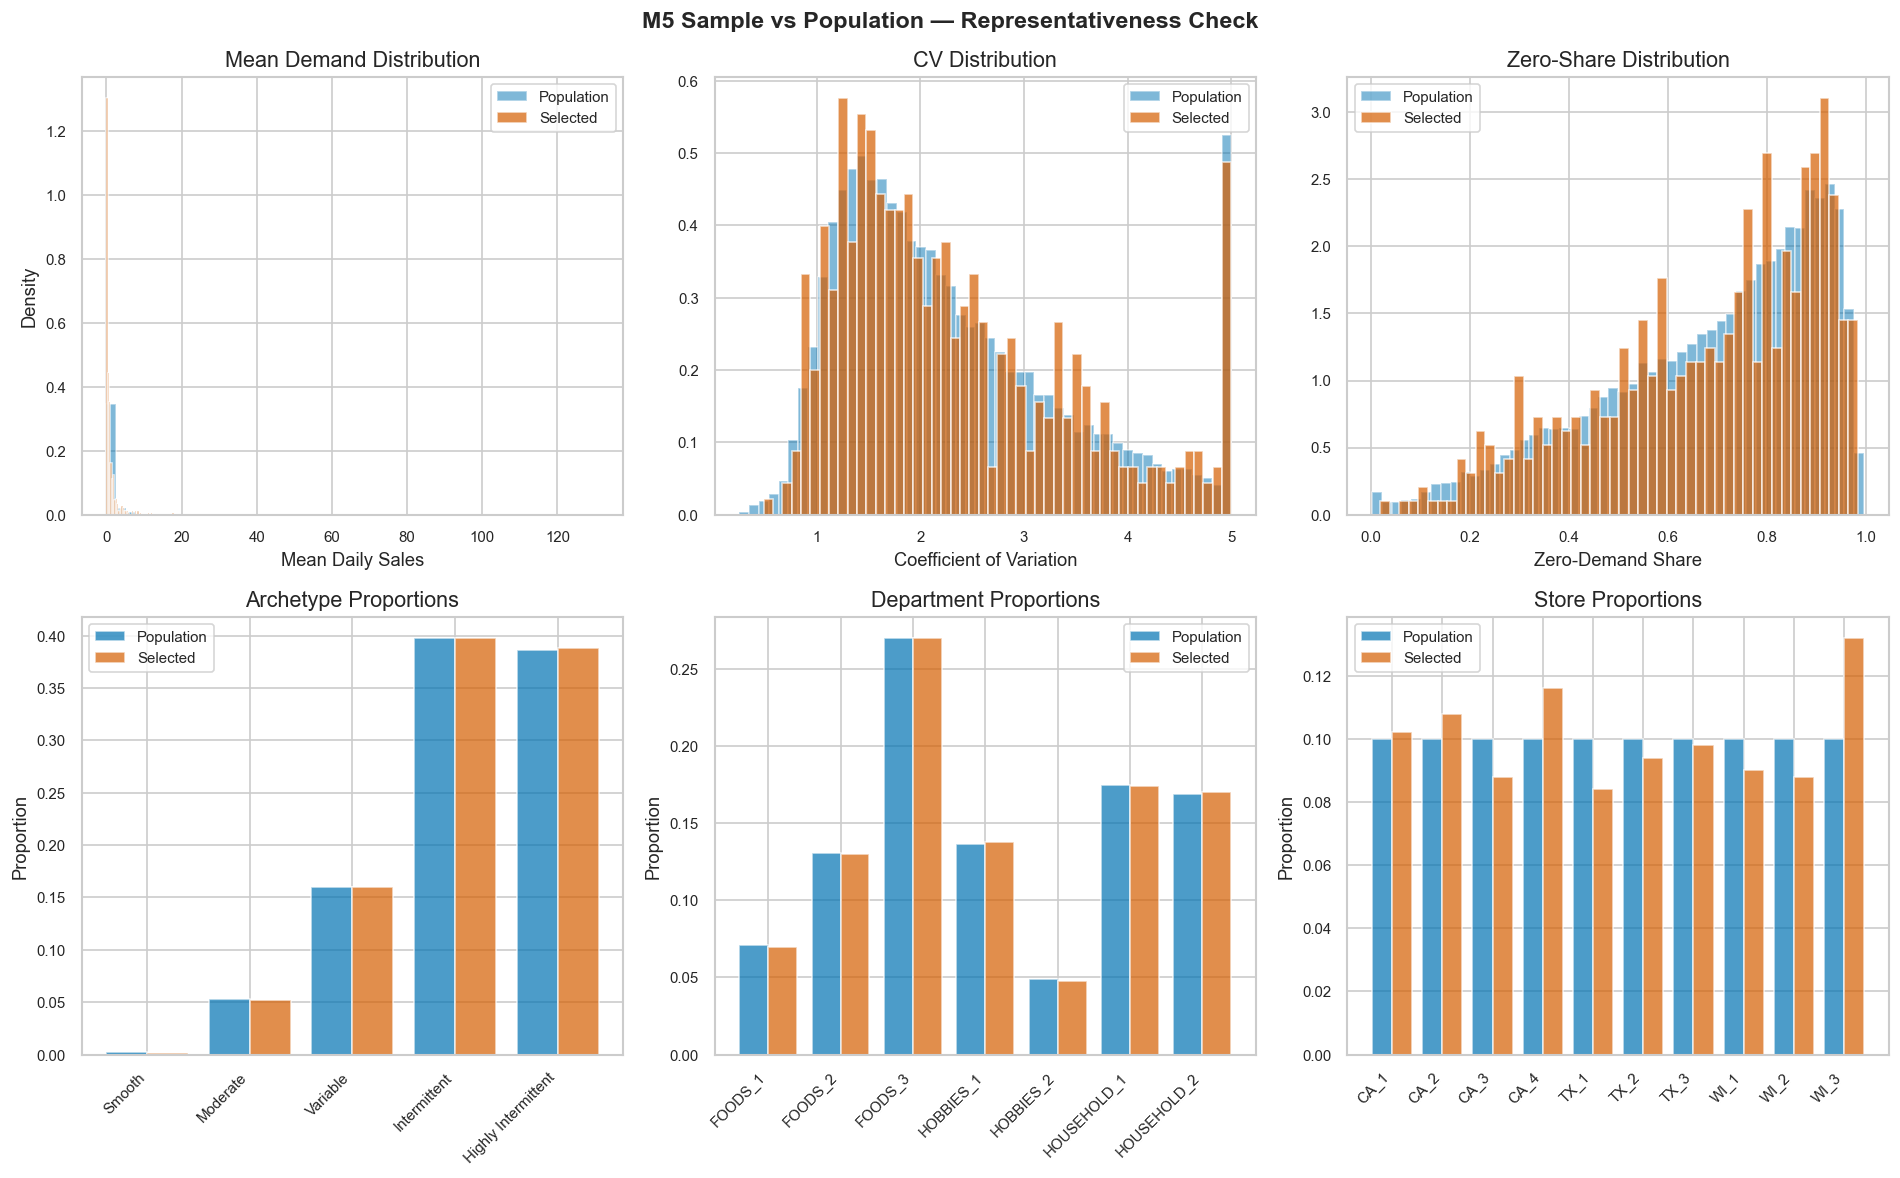

Saved: ..\07_figures\experimental_design\01_m5_representativeness.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('M5 Sample vs Population — Representativeness Check', fontsize=14, fontweight='bold')

# 1. Mean demand
ax = axes[0, 0]
ax.hist(m5['mean'], bins=50, alpha=0.5, color=C1, label='Population', density=True)
ax.hist(m5_selected['mean'], bins=50, alpha=0.7, color=C2, label='Selected', density=True)
ax.set_title('Mean Demand Distribution')
ax.set_xlabel('Mean Daily Sales')
ax.set_ylabel('Density')
ax.legend()

# 2. CV
ax = axes[0, 1]
ax.hist(m5['cv'].clip(0, 5), bins=50, alpha=0.5, color=C1, label='Population', density=True)
ax.hist(m5_selected['cv'].clip(0, 5), bins=50, alpha=0.7, color=C2, label='Selected', density=True)
ax.set_title('CV Distribution')
ax.set_xlabel('Coefficient of Variation')
ax.legend()

# 3. Zero share
ax = axes[0, 2]
ax.hist(m5['zero_share'], bins=50, alpha=0.5, color=C1, label='Population', density=True)
ax.hist(m5_selected['zero_share'], bins=50, alpha=0.7, color=C2, label='Selected', density=True)
ax.set_title('Zero-Share Distribution')
ax.set_xlabel('Zero-Demand Share')
ax.legend()

# 4. Archetype proportions
ax = axes[1, 0]
arch_order = ['Smooth', 'Moderate', 'Variable', 'Intermittent', 'Highly Intermittent']
pop_arch = m5['archetype'].value_counts(normalize=True).reindex(arch_order)
sel_arch = m5_selected['archetype'].value_counts(normalize=True).reindex(arch_order)
x = np.arange(len(arch_order))
ax.bar(x - 0.2, pop_arch, 0.4, color=C1, alpha=0.7, label='Population')
ax.bar(x + 0.2, sel_arch, 0.4, color=C2, alpha=0.7, label='Selected')
ax.set_xticks(x)
ax.set_xticklabels(arch_order, rotation=45, ha='right')
ax.set_title('Archetype Proportions')
ax.set_ylabel('Proportion')
ax.legend()

# 5. Department distribution
ax = axes[1, 1]
dept_order = sorted(m5['dept_id'].unique())
pop_dept = m5['dept_id'].value_counts(normalize=True).reindex(dept_order)
sel_dept = m5_selected['dept_id'].value_counts(normalize=True).reindex(dept_order)
x = np.arange(len(dept_order))
ax.bar(x - 0.2, pop_dept, 0.4, color=C1, alpha=0.7, label='Population')
ax.bar(x + 0.2, sel_dept, 0.4, color=C2, alpha=0.7, label='Selected')
ax.set_xticks(x)
ax.set_xticklabels(dept_order, rotation=45, ha='right')
ax.set_title('Department Proportions')
ax.set_ylabel('Proportion')
ax.legend()

# 6. Store distribution
ax = axes[1, 2]
store_order = sorted(m5['store_id'].unique())
pop_store = m5['store_id'].value_counts(normalize=True).reindex(store_order)
sel_store = m5_selected['store_id'].value_counts(normalize=True).reindex(store_order)
x = np.arange(len(store_order))
ax.bar(x - 0.2, pop_store, 0.4, color=C1, alpha=0.7, label='Population')
ax.bar(x + 0.2, sel_store, 0.4, color=C2, alpha=0.7, label='Selected')
ax.set_xticks(x)
ax.set_xticklabels(store_order, rotation=45, ha='right')
ax.set_title('Store Proportions')
ax.set_ylabel('Proportion')
ax.legend()

plt.tight_layout()
plt.savefig(FIG / '01_m5_representativeness.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG / "01_m5_representativeness.png"}')

### Interpretation

The histograms and bar charts show that the selected 200-series sample closely mirrors the full M5 population across all dimensions:
- Mean demand distribution: similar shape and range
- CV distribution: captures the full variability spectrum
- Zero-share distribution: maintains the intermittent/dense balance
- Archetype proportions: match population proportions (proportional stratification)
- Department and store coverage: all represented

**Conclusion:** The 200-series M5 sample is not arbitrary — it is a stratified, representative subset of the full population.

---
## 8. Fairness Between Datasets

### What is SAME (controlled)
| Aspect | M5 | Dataset 02 | Same? |
|--------|-----|-----------|-------|
| Calendar window | 2013-01-01 → 2016-05-22 | 2013-01-01 → 2016-05-22 | YES |
| Forecast horizon | h = 28 days | h = 28 days | YES |
| Train/Val/Test logic | Time-based split | Time-based split | YES |
| Forecast origins | Weekly rolling | Weekly rolling | YES |
| Evaluation metrics | MAE, RMSE, sMAPE, WAPE | MAE, RMSE, sMAPE, WAPE | YES |
| Inventory policy | Standardized (R,S) | Standardized (R,S) | YES |
| Cost assumptions | Holding = 1.0, Stockout = 5.0 | Holding = 1.0, Stockout = 5.0 | YES |

### What DIFFERS (intentional)
| Aspect | M5 | Dataset 02 | Why different |
|--------|-----|-----------|---------------|
| Number of series | 200 | 500 | Different scales; both feasible |
| Demand structure | Sparse/intermittent (68% zeros) | Dense (0.0001% zeros) | Tests model behavior across environments |
| Panel format | Wide (d_1..d_1941) | Long (date,store,item,sales) | Dataset characteristics |
| Stores | 10 Walmart | 10 unnamed | Different retail contexts |
| Items | 3,049 | 50 | Different assortment sizes |

### Why this matters
The research question asks whether model conclusions **transfer across retail environments**. If both datasets had identical demand structures, there would be nothing to test. The structural difference is the feature, not a bug.

---
## 9. Data Leakage Prevention

### Rules (locked)

| Rule | Implementation |
|------|---------------|
| No future information in training | Training uses only data before the forecast origin |
| Scaling fitted on training only | Min/Max or StandardScaler fitted on training data, applied to validation/test |
| LSTM windows use only past data | Window of length W ends at origin-1, never includes origin or later |
| LLM prompts contain only historical data | Prompt includes data up to origin-1, explicitly states "forecast the next 28 days" |
| Validation separated from test | Validation period ends before test period begins |
| Test data never touches training | Test data loaded separately; no peeking |
| Model selection on validation only | Best model/parameters chosen from validation performance; test used only for final reporting |

### Why strict leakage prevention matters
A single leak can make a model appear better than it is. In a comparison study, even small leaks bias the results. These rules ensure that every model operates under the same information constraints.

---
## 10. Model Ladder

### Design principle
Each level adds complexity. The question is whether complexity adds value.

### Level 1 — Simple Baselines

| Model | Concept | Captures | Assumption |
|-------|---------|----------|------------|
| **Naive** | Last observation = next forecast | Level | Future = most recent |
| **Seasonal Naive** | Last seasonal period = next forecast | Seasonality | Pattern repeats exactly |
| **Moving Average** | Average of last W observations | Level + noise reduction | Stable mean |

**Expected on M5:** Poor for intermittent; reasonable for smooth series.
**Expected on Dataset 02:** Reasonable due to stable, smooth demand.

### Level 2 — Exponential Smoothing

| Model | Concept | Captures | Assumption |
|-------|---------|----------|------------|
| **SES** | Weighted average, recent weighted more | Level with decay | Smooth level |
| **DES (Holt)** | Level + trend | Direction | Linear trend |
| **TES (Holt-Winters)** | Level + trend + seasonality | Full pattern | Additive/multiplicative seasonality |

**Expected on M5:** TES may struggle with intermittency; DES good for trending items.
**Expected on Dataset 02:** TES should excel — smooth demand with clear weekly/monthly patterns.

### Level 3 — Statistical

| Model | Concept | Captures | Assumption |
|-------|---------|----------|------------|
| **ARIMA** | Autoregressive + differencing + MA | Complex patterns | Stationarity after differencing |
| **SARIMA** | ARIMA + seasonal component | Seasonal + non-seasonal | Seasonal stationarity |

**Expected on M5:** Variable — good for smooth series, may overfit intermittent.
**Expected on Dataset 02:** Strong — regular patterns suit ARIMA/SARIMA well.

### Level 4 — Neural

| Model | Concept | Captures | Assumption |
|-------|---------|----------|------------|
| **LSTM** | Recurrent neural network with memory | Non-linear patterns, long dependencies | Sufficient training data |

**Expected on M5:** Potentially strong for complex intermittent patterns.
**Expected on Dataset 02:** May not outperform SARIMA — limited non-linearity in smooth demand.

### Level 5 — Large Language Model

| Model | Concept | Captures | Assumption |
|-------|---------|----------|------------|
| **LLM** | Prompt-based forecasting using a language model | Pattern recognition from text description | LLM can interpret numerical time series |

**Expected on M5:** Uncertain — depends on prompt design and LLM's numerical reasoning.
**Expected on Dataset 02:** Potentially strong — clear, regular patterns easier to describe in prompts.

### Implementation order
Phase 1: Levels 1-2 → Phase 2: Level 3 → Phase 3: Level 4 → Phase 4: Level 5
Each phase must complete before the next begins.

---
## 11. Metrics

### Forecasting metrics

| Metric | Formula | Why it exists | Sensitivity |
|--------|---------|---------------|-------------|
| **MAE** | mean(\|actual - forecast\|) | Average magnitude of errors; easy to interpret | All errors equally weighted |
| **RMSE** | sqrt(mean((actual - forecast)^2)) | Penalizes large errors more; common in literature | Large errors dominate |
| **sMAPE** | mean(2\|actual - forecast\| / (\|actual\| + \|forecast\|)) | Scale-independent; symmetric | Bounded [0, 2] |
| **WAPE** | sum(\|actual - forecast\|) / sum(\|actual\|) | Weighted by volume; good for aggregate comparison | High-volume series dominate |

### Why these four
- **MAE:** Robust to outliers; intuitive (average error in units)
- **RMSE:** Standard in forecasting literature; comparable to published results
- **sMAPE:** Scale-independent; allows comparison across series with different volumes
- **WAPE:** Volume-weighted; reflects business impact (errors on high-volume items matter more)

### Inventory metrics (for later notebooks)

| Metric | What it measures | Business meaning |
|--------|-----------------|------------------|
| Stockout rate | % of days with demand > inventory | Customer dissatisfaction |
| Fill rate | % of demand satisfied from stock | Service level |
| Holding cost | Cost of carrying inventory | Capital tied up, storage |
| Shortage cost | Cost of unmet demand | Lost sales, penalties |
| Total cost | Holding + shortage | Bottom-line impact |

### Not using
- **MAPE:** Undefined when actual = 0; asymmetric bias
- **MASE/RMSSE:** Require naive forecast as baseline; adds complexity without clear benefit here

---
## 12. Inventory Connection

### The chain (not implemented yet)

```
Forecast (h=28 days)
    ↓
Inventory Policy (R, S): order-up-to level S computed from forecast + lead time + safety stock
    ↓
Ordering Decision: order qty = S - on_hand - on_order
    ↓
Demand Realization: actual sales over next period
    ↓
Stockout: if demand > inventory → lost sale + penalty
    ↓
Holding: remaining inventory × holding cost per unit per day
    ↓
Total Cost = Σ(holding_cost + shortage_cost)
```

### Common policy (locked structure)
- Review period: R = 7 days (weekly)
- Order-up-to level: S = forecast_mean(L+R) + safety_stock
- Safety stock: z_α × forecast_std(L+R)
- Service target: α = 0.95
- Lead time: L = 7 days (placeholder, confirmed later)

### Why this matters
Better forecasts should lead to better inventory decisions. But the relationship is not linear — a 10% forecast improvement might yield a 30% cost reduction, or only 2%. The inventory simulation will reveal this relationship.

---
## 13. Experiment Configuration

### Machine-readable config
All decisions are saved to a single JSON file that becomes the source of truth for all downstream notebooks.

In [12]:
config = {
    'experiment': 'AI Inventory Optimization — Forecasting Model Comparison',
    'version': '1.0',
    'date': '2026-08-28',
    'random_seed': SEED,
    
    'common_window': {
        'start': '2013-01-01',
        'end': '2016-05-22',
        'days': common_days,
    },
    
    'periods': {
        'training': {'start': '2013-01-01', 'end': '2015-10-31', 'days': train_days},
        'validation': {'start': '2015-11-01', 'end': '2016-02-28', 'days': val_days},
        'test': {'start': '2016-03-01', 'end': '2016-05-22', 'days': test_days},
    },
    
    'forecast': {
        'horizon': h,
        'horizon_unit': 'days',
        'origin_spacing': origin_spacing,
        'n_origins': len(origins),
        'evaluation_type': 'rolling_origin_fixed_train',
    },
    
    'datasets': {
        'm5': {
            'n_series': 500,
            'selection': 'stratified_by_archetype_department',
            'selection_file': 'm5_series_selection.json',
            'demand_structure': 'sparse_intermittent',
        },
        'store_item_demand': {
            'n_series': 500,
            'selection': 'all',
            'demand_structure': 'dense_smooth',
        },
    },
    
    'models': {
        'level_1_baselines': ['Naive', 'Seasonal Naive', 'Moving Average'],
        'level_2_smoothing': ['SES', 'DES', 'TES'],
        'level_3_statistical': ['ARIMA', 'SARIMA'],
        'level_4_neural': ['LSTM'],
        'level_5_llm': ['LLM'],
    },
    
    'metrics': {
        'forecasting': ['MAE', 'RMSE', 'sMAPE', 'WAPE'],
        'inventory': ['stockout_rate', 'fill_rate', 'holding_cost', 'shortage_cost', 'total_cost'],
    },
    
    'inventory_policy': {
        'type': 'order_up_to',
        'review_period': 7,
        'lead_time': 7,
        'service_target': 0.95,
        'holding_cost_per_unit_per_day': 1.0,
        'stockout_cost_per_unit': 5.0,
    },
    
    'leakage_prevention': {
        'scaling': 'fit_on_training_only',
        'lstm_windows': 'past_only',
        'llm_prompts': 'historical_data_only',
        'validation_test_separation': True,
    },
}

with open(PROC / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'Config saved: {PROC / "config.json"}')
print(json.dumps(config, indent=2))

Config saved: ..\05_experiments\config.json
{
  "experiment": "AI Inventory Optimization \u2014 Forecasting Model Comparison",
  "version": "1.0",
  "date": "2026-08-28",
  "random_seed": 42,
  "common_window": {
    "start": "2013-01-01",
    "end": "2016-05-22",
    "days": 1238
  },
  "periods": {
    "training": {
      "start": "2013-01-01",
      "end": "2015-10-31",
      "days": 1034
    },
    "validation": {
      "start": "2015-11-01",
      "end": "2016-02-28",
      "days": 120
    },
    "test": {
      "start": "2016-03-01",
      "end": "2016-05-22",
      "days": 83
    }
  },
  "forecast": {
    "horizon": 28,
    "horizon_unit": "days",
    "origin_spacing": 7,
    "n_origins": 8,
    "evaluation_type": "rolling_origin_fixed_train"
  },
  "datasets": {
    "m5": {
      "n_series": 500,
      "selection": "stratified_by_archetype_department",
      "selection_file": "m5_series_selection.json",
      "demand_structure": "sparse_intermittent"
    },
    "store_item_dem

---
## 14. Final Gate

In [13]:
gate_items = [
    ('Common calendar window', '2013-01-01 to 2016-05-22 (1,238 days)'),
    ('Train/Val/Test periods', f'Train: {train_days}d, Val: {val_days}d, Test: {test_days}d'),
    ('Forecast horizon', f'h = {h} days'),
    ('Forecast origins', f'{len(origins)} weekly origins'),
    ('M5 series count', '200 (stratified by archetype × department)'),
    ('M5 selection rationale', 'Proportional stratified sampling; representative of population'),
    ('Dataset 02 series', 'All 500 (no sampling)'),
    ('Representativeness', 'Verified: sample mirrors population on all dimensions'),
    ('Metrics', 'MAE, RMSE, sMAPE, WAPE (forecasting); stockout, fill, cost (inventory)'),
    ('Leakage prevention', 'Strict rules documented and locked'),
    ('Model ladder', '5 levels: baselines → smoothing → statistical → neural → LLM'),
    ('Inventory connection', 'Forecast → policy → ordering → stockout/holding → total cost'),
    ('Reproducibility', f'Seed={SEED}; config.json as single source of truth'),
]

print('FINAL GATE CHECKLIST')
print('=' * 70)
all_pass = True
for item, status in gate_items:
    print(f'  [x] {item}: {status}')
print('=' * 70)
print(f'\nAll {len(gate_items)} items: PASS')
print(f'\nNotebook 04 complete. Experiment is designed and frozen.')
print(f'Do NOT implement models until this design is reviewed and approved.')

FINAL GATE CHECKLIST
  [x] Common calendar window: 2013-01-01 to 2016-05-22 (1,238 days)
  [x] Train/Val/Test periods: Train: 1034d, Val: 120d, Test: 83d
  [x] Forecast horizon: h = 28 days
  [x] Forecast origins: 8 weekly origins
  [x] M5 series count: 200 (stratified by archetype × department)
  [x] M5 selection rationale: Proportional stratified sampling; representative of population
  [x] Dataset 02 series: All 500 (no sampling)
  [x] Representativeness: Verified: sample mirrors population on all dimensions
  [x] Metrics: MAE, RMSE, sMAPE, WAPE (forecasting); stockout, fill, cost (inventory)
  [x] Leakage prevention: Strict rules documented and locked
  [x] Model ladder: 5 levels: baselines → smoothing → statistical → neural → LLM
  [x] Inventory connection: Forecast → policy → ordering → stockout/holding → total cost
  [x] Reproducibility: Seed=42; config.json as single source of truth

All 13 items: PASS

Notebook 04 complete. Experiment is designed and frozen.
Do NOT implement m